In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
df = pd.read_csv("adultcensusincome.csv")

In [5]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,Female,0,3900,40,United-States,<=50K


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   sex             32561 non-null  object
 9   capital.gain    32561 non-null  int64 
 10  capital.loss    32561 non-null  int64 
 11  hours.per.week  32561 non-null  int64 
 12  native.country  32561 non-null  object
 13  income          32561 non-null  object
dtypes: int64(6), object(8)
memory usage: 3.5+ MB


In [7]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [8]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [9]:
question_marks = (df == '?').sum()
display(question_marks[question_marks > 0])

workclass         1836
occupation        1843
native.country     583
dtype: int64

In [10]:
df.replace('?', pd.NA, inplace=True)
df.dropna(inplace=True)

In [11]:
df.shape

(30162, 14)

In [12]:
df['income'].value_counts()

income
<=50K    22654
>50K      7508
Name: count, dtype: int64

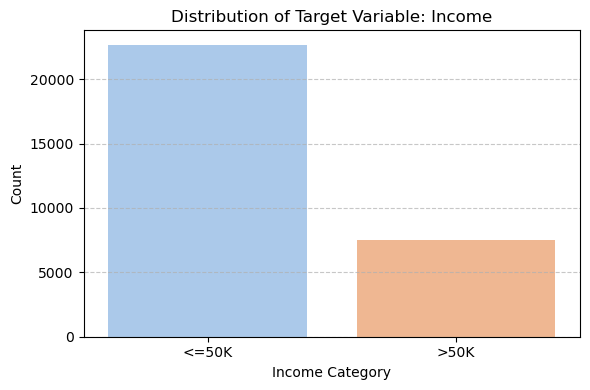

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='income', data=df, hue='income', palette='pastel')
plt.title("Distribution of Target Variable: Income")
plt.xlabel("Income Category")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [14]:
df['income'].value_counts(normalize=True)

income
<=50K    0.751078
>50K     0.248922
Name: proportion, dtype: float64

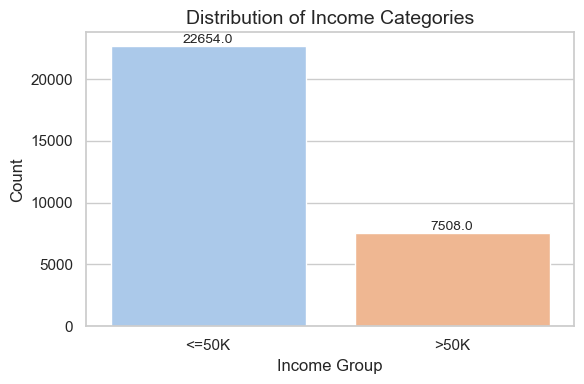

In [15]:
sns.set(style="whitegrid")

plt.figure(figsize=(6,4))
sns.countplot(x='income', data=df, hue='income', palette='pastel')

for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                       ha='center', va='bottom', fontsize=10)

plt.title("Distribution of Income Categories", fontsize=14)
plt.xlabel("Income Group", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()


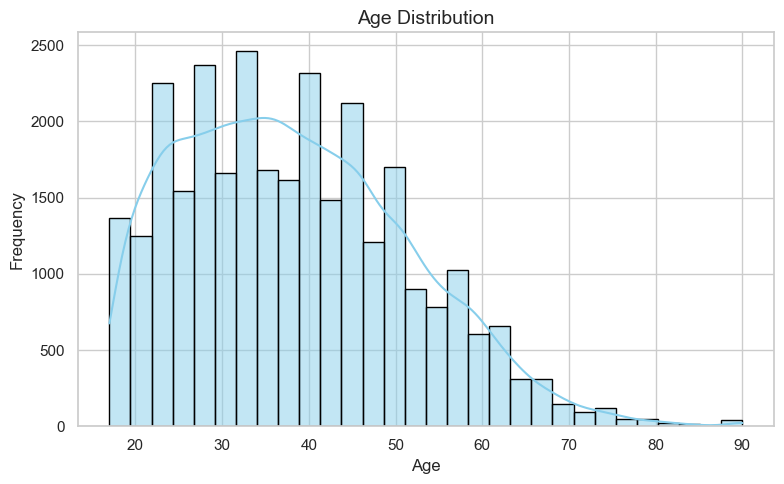

In [16]:
sns.set(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', bins=30, kde=True, color='skyblue', edgecolor='black')

plt.title("Age Distribution", fontsize=14)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()


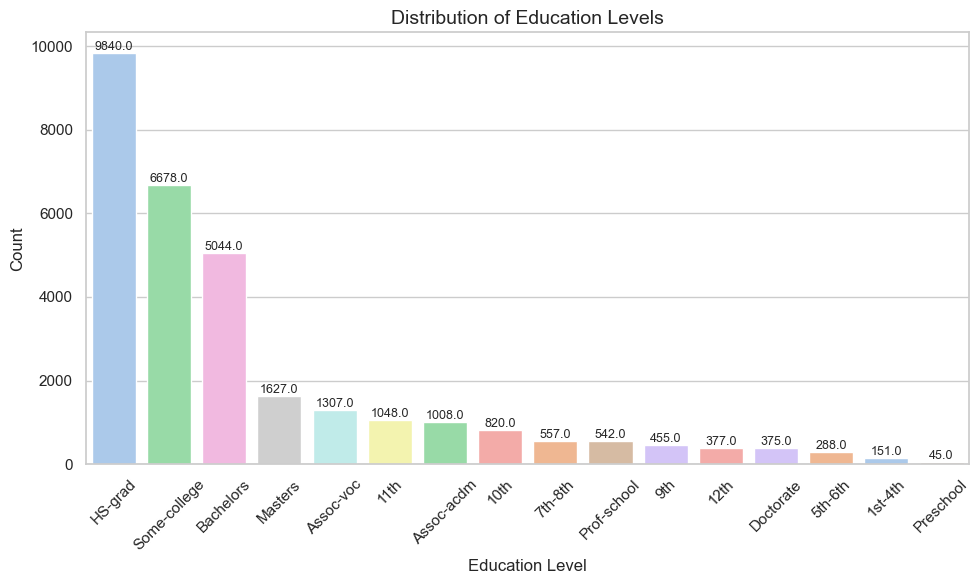

In [17]:
sns.set(style="whitegrid")

edu_order = df['education'].value_counts().sort_values(ascending=False).index

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='education', order=edu_order, hue='education', palette='pastel')

for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().annotate(f'{height}', 
                       (p.get_x() + p.get_width() / 2., height),
                       ha='center', va='bottom', fontsize=9)

# Labeling
plt.title("Distribution of Education Levels", fontsize=14)
plt.xlabel("Education Level", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


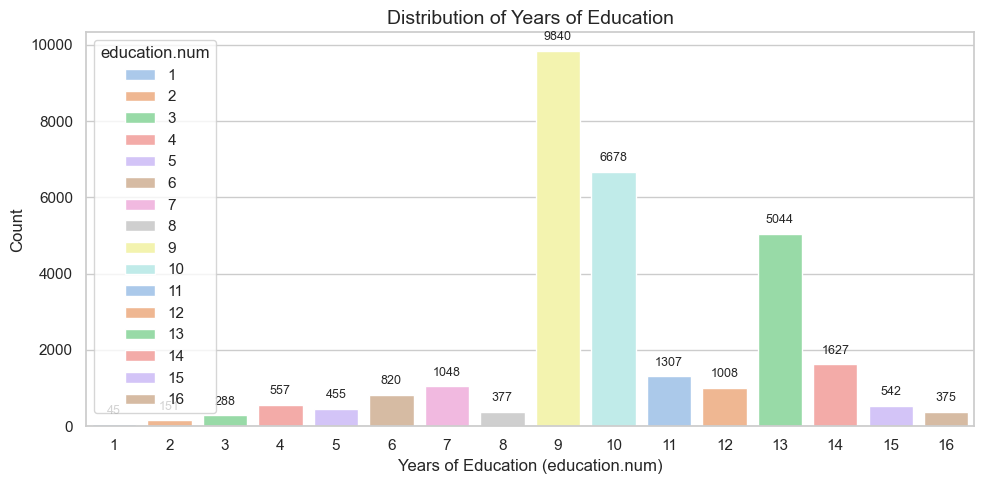

In [18]:
sns.set(style="whitegrid")

edu_years_counts = df['education.num'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=edu_years_counts.index, y=edu_years_counts.values, hue=edu_years_counts.index, palette='pastel')

for i, value in enumerate(edu_years_counts.values):
    plt.text(i, value + 200, str(value), ha='center', va='bottom', fontsize=9)

plt.title("Distribution of Years of Education", fontsize=14)
plt.xlabel("Years of Education (education.num)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


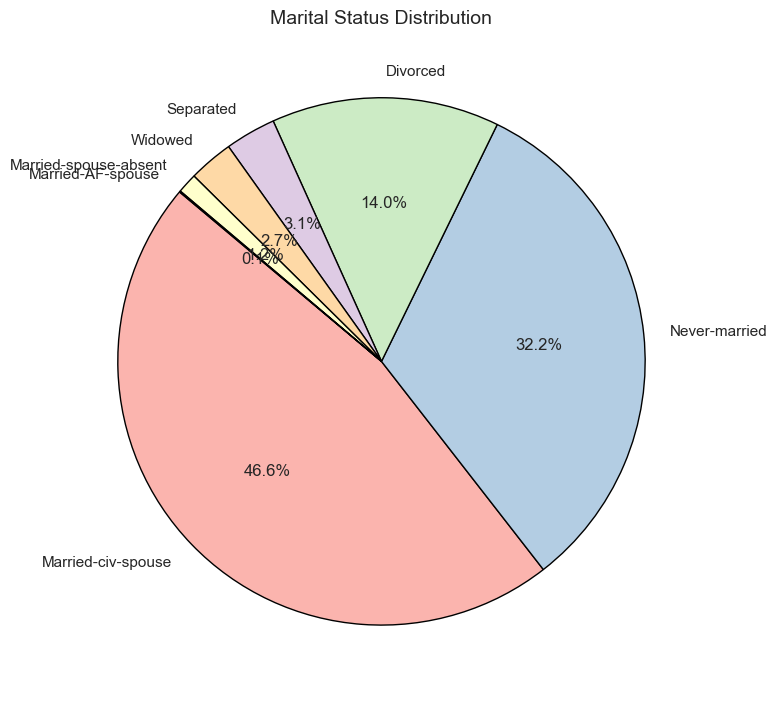

In [19]:
marital_counts = df['marital.status'].value_counts()


plt.figure(figsize=(8, 8))
plt.pie(
    marital_counts.values,
    labels=marital_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Pastel1.colors,
    wedgeprops={'edgecolor': 'black'}
)

plt.title("Marital Status Distribution", fontsize=14)
plt.tight_layout()
plt.show()


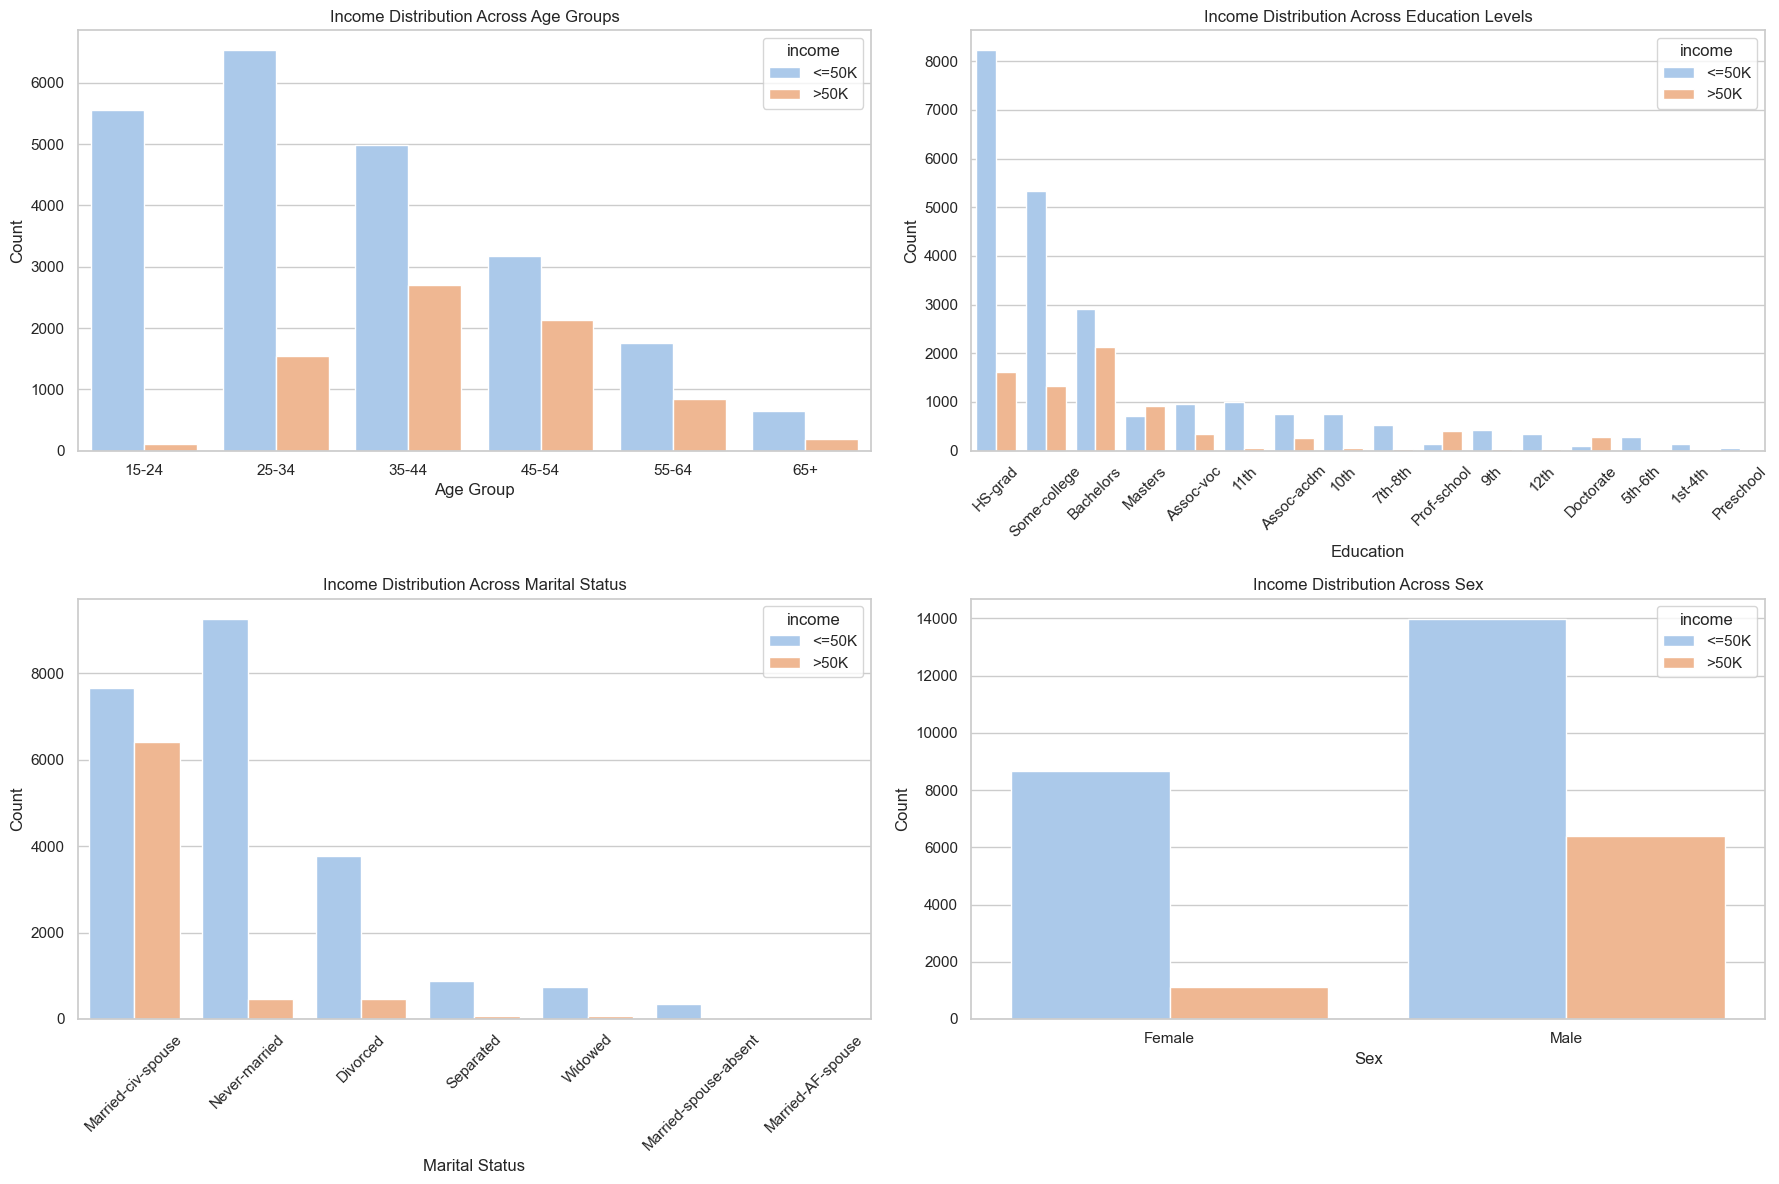

In [20]:
sns.set(style="whitegrid")

plt.figure(figsize=(18, 12))

df['age_bin'] = pd.cut(df['age'], bins=[15, 25, 35, 45, 55, 65, 100], 
                       labels=['15-24', '25-34', '35-44', '45-54', '55-64', '65+'])

# 1. Income vs Age
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='age_bin', hue='income', palette='pastel')
plt.title('Income Distribution Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Count')

# 2. Income vs Education
plt.subplot(2, 2, 2)
edu_order = df['education'].value_counts().sort_values(ascending=False).index
sns.countplot(data=df, x='education', hue='income', order=edu_order, palette='pastel')
plt.title('Income Distribution Across Education Levels')
plt.xlabel('Education')
plt.ylabel('Count')
plt.xticks(rotation=45)

# 3. Income vs Marital Status
plt.subplot(2, 2, 3)
marital_order = df['marital.status'].value_counts().index
sns.countplot(data=df, x='marital.status', hue='income', order=marital_order, palette='pastel')
plt.title('Income Distribution Across Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.xticks(rotation=45)

# 4. Income vs Sex
plt.subplot(2, 2, 4)
sns.countplot(data=df, x='sex', hue='income', palette='pastel')
plt.title('Income Distribution Across Sex')
plt.xlabel('Sex')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

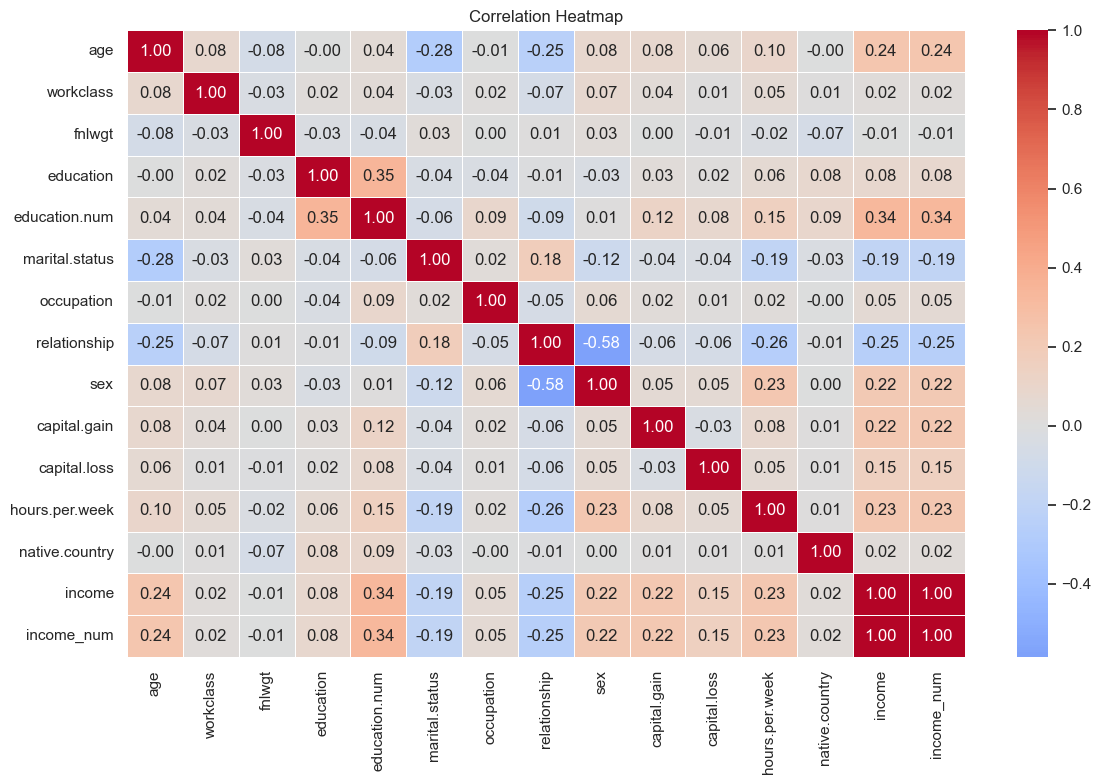

Features Most Positively Correlated with Income:
income           1.000000
education.num    0.335286
age              0.241998
Name: income_num, dtype: float64 

Features Most Negatively Correlated with Income:
fnlwgt           -0.008957
marital.status   -0.193518
relationship     -0.251003
Name: income_num, dtype: float64


In [21]:
# Convert 'income' to numeric: >50K → 1, <=50K → 0
df_corr = df.copy()
df_corr['income_num'] = df_corr['income'].apply(lambda x: 1 if x.strip() == '>50K' else 0)

# Convert categorical columns to category codes for correlation calculation
for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = df_corr[col].astype('category').cat.codes

# Compute correlation matrix
corr_matrix = df_corr.corr(numeric_only=True)

# Draw heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Sort correlations with income
income_corr = corr_matrix['income_num'].drop('income_num').sort_values(ascending=False)

# Show top positively and negatively correlated features
print("Features Most Positively Correlated with Income:")
print(income_corr.head(3), "\n")

print("Features Most Negatively Correlated with Income:")
print(income_corr.tail(3))


In [22]:
from sklearn.preprocessing import LabelEncoder

# Make a copy to avoid modifying the original DataFrame
df_encoded = df.copy()

# Initialize LabelEncoder
le = LabelEncoder()

# Identify categorical columns (object or string types)
cat_cols = df_encoded.select_dtypes(include=['object']).columns

# Apply Label Encoding to each categorical column
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Display encoded column types and preview
print("Label Encoded Columns:")
print(cat_cols.tolist())
df_encoded.head()


Label Encoded Columns:
['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'sex', 'native.country', 'income']


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,sex,capital.gain,capital.loss,hours.per.week,native.country,income,age_bin
1,82,2,132870,11,9,6,3,1,0,0,4356,18,38,0,65+
3,54,2,140359,5,4,0,6,4,0,0,3900,40,38,0,45-54
4,41,2,264663,15,10,5,9,3,0,0,3900,40,38,0,35-44
5,34,2,216864,11,9,0,7,4,0,0,3770,45,38,0,25-34
6,38,2,150601,0,6,5,0,4,1,0,3770,40,38,0,35-44


In [23]:
# Define the dependent variable (target)
y = df_encoded['income']

# Define independent variables (features)
X = df_encoded.drop('income', axis=1)

# Show shapes and preview
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print("\nTarget variable (y) preview:")
print(y.value_counts())

print("\nFeature matrix (X) preview:")
print(X.head())


X shape: (30162, 14)
y shape: (30162,)

Target variable (y) preview:
income
0    22654
1     7508
Name: count, dtype: int64

Feature matrix (X) preview:
   age  workclass  fnlwgt  education  education.num  marital.status  \
1   82          2  132870         11              9               6   
3   54          2  140359          5              4               0   
4   41          2  264663         15             10               5   
5   34          2  216864         11              9               0   
6   38          2  150601          0              6               5   

   occupation  relationship  sex  capital.gain  capital.loss  hours.per.week  \
1           3             1    0             0          4356              18   
3           6             4    0             0          3900              40   
4           9             3    0             0          3900              40   
5           7             4    0             0          3770              45   
6           0       

In [24]:
display(X.dtypes)

age                  int64
workclass            int64
fnlwgt               int64
education            int64
education.num        int64
marital.status       int64
occupation           int64
relationship         int64
sex                  int64
capital.gain         int64
capital.loss         int64
hours.per.week       int64
native.country       int64
age_bin           category
dtype: object

In [25]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Drop non-numeric helper column if it exists
X_fixed = X.drop(columns=['age_bin'], errors='ignore')  # 'errors="ignore"' avoids crash if column doesn't exist

# Split before scaling and resampling
X_train, X_test, y_train, y_test = train_test_split(
    X_fixed, y, test_size=0.2, stratify=y, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

# Print summary
print("Shapes After Preprocessing:")
print(f"X_train_balanced: {X_train_balanced.shape}")
print(f"y_train_balanced: {y_train_balanced.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")
print(f"y_test: {y_test.shape}")

print("\nTarget Distribution After SMOTE (Training Set):")
print(y_train_balanced.value_counts())

Shapes After Preprocessing:
X_train_balanced: (36246, 13)
y_train_balanced: (36246,)
X_test_scaled: (6033, 13)
y_test: (6033,)

Target Distribution After SMOTE (Training Set):
income
0    18123
1    18123
Name: count, dtype: int64


/opt/anaconda3/envs/learn/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [26]:
from sklearn.model_selection import train_test_split

# Perform the split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,        # 20% for testing
    random_state=42,      # Ensures reproducibility
    stratify=y            # Keeps target distribution balanced in both sets
)

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Prepare clean numeric-only X and y
X_clean = df_encoded.drop(columns=['age_bin'], errors='ignore')  # remove age_bin if present
y_clean = X_clean['income']
X_clean = X_clean.drop(columns=['income'])

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

# 3. Initialize classifiers
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "KNN Classifier": KNeighborsClassifier(),
    "SVM Classifier": SVC(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# 4. Train and evaluate
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

# 5. Summary
print("\nModel Accuracy Summary:")
for model, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{model:<20}: {acc:.4f}")


/opt/anaconda3/envs/learn/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.8084
KNN Classifier Accuracy: 0.7703
SVM Classifier Accuracy: 0.7885
Naive Bayes Accuracy: 0.7908
Decision Tree Accuracy: 0.8110
Random Forest Accuracy: 0.8584

Model Accuracy Summary:
Random Forest       : 0.8584
Decision Tree       : 0.8110
Logistic Regression : 0.8084
Naive Bayes         : 0.7908
SVM Classifier      : 0.7885
KNN Classifier      : 0.7703


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.exceptions import ConvergenceWarning
import warnings

# 1. Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "KNN Classifier": KNeighborsClassifier(),
    "SVM Classifier": SVC(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# 3. Train and evaluate all models
results = {}

# Suppress convergence warnings for clean output
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ConvergenceWarning)

    for name, model in models.items():
        # Use scaled features for models that benefit from it
        if name in ["Logistic Regression", "KNN Classifier", "SVM Classifier"]:
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        results[name] = acc
        print(f"{name} Accuracy: {acc:.4f}")

# 4. Summary
print("\nModel Accuracy Summary (Descending):")
for model, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{model:<20}: {acc:.4f}")


Logistic Regression Accuracy: 0.8314
KNN Classifier Accuracy: 0.8326
SVM Classifier Accuracy: 0.8490
Naive Bayes Accuracy: 0.7908
Decision Tree Accuracy: 0.8110
Random Forest Accuracy: 0.8584

Model Accuracy Summary (Descending):
Random Forest       : 0.8584
SVM Classifier      : 0.8490
KNN Classifier      : 0.8326
Logistic Regression : 0.8314
Decision Tree       : 0.8110
Naive Bayes         : 0.7908
